# MLOps Assignment: Predictive Maintenance Classification
### Starter Notebook

**Domain:** Industrial IoT / Manufacturing
**Task:** Multi-class failure type prediction
**Tools:** Pandera ? MLflow ? Optuna ? Evidently ? SHAP

---

## Business Context

A heavy-equipment manufacturer runs 10,000+ machines on the shop floor.
Each machine continuously streams six sensor readings. When a machine fails,
production halts at a cost of 8-15 lakh per hour of downtime.

Your job is to build a full MLOps pipeline that:
1. Validates incoming sensor data before it enters the pipeline (Pandera)
2. Trains and tracks a multi-class failure classifier (MLflow)
3. Tunes hyperparameters and registers the best model (Optuna + MLflow Registry)
4. Monitors the deployed model for distributional shift (Evidently)
5. Explains why the model predicts a specific failure type (SHAP)

**Files provided:**
- `data/train.csv`: 6,993 labelled sensor readings (historical baseline)
- `data/current.csv`: 1,499 readings from the current stable production batch
- `data/stress.csv`: 1,499 readings from a heavy-load production period

**Failure classes:**

| Code | Name | Description |
|------|------|-------------|
| 0 | No Failure | Machine operating normally |
| 1 | TWF | Tool Wear Failure |
| 2 | HDF | Heat Dissipation Failure |
| 3 | PWF | Power Failure |
| 4 | OSF | Overstrain Failure |


> **Visual anchor:** Use the generated `eda_distributions.png` early (Section 1.3) to ground your expectations before drift and SHAP interpretation.

> **Stress-batch goal:** Diagnose *why* the model is stale under shifted operating conditions, not to force perfect predictions on `stress.csv`.

> **Submission:** Submit this notebook (`.ipynb`) with all cells executed.

> **Do not change the section structure or remove any markdown cells.**

## **1. Data Loading, Schema Validation & EDA** <font color=red>[15 marks]</font>

### **1.1** <font color=red>[3 marks]</font> Load the datasets

Load `train.csv`, `current.csv`, and `stress.csv` from the `data/` folder.
Print the shape of each and display the first 5 rows of the training set.


In [30]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['DISABLE_PANDERA_IMPORT_WARNING'] = 'True'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: Load the three datasets
train   = pd.read_csv('train.csv')
current = pd.read_csv('current.csv')
stress  = pd.read_csv('stress.csv')

# TODO: Print shapes
print('Train shape:', train.shape)
print('Current shape:', current.shape)
print('Stress shape:', stress.shape)

CLASS_NAMES = {0: 'No Failure', 1: 'TWF', 2: 'HDF', 3: 'PWF', 4: 'OSF'}

# TODO: Display first 5 rows of train
train.head()


Train shape: (6993, 7)
Current shape: (1499, 7)
Stress shape: (1499, 7)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Failure_Type
0,L,302.5,311.1,1499,38.8,135,0
1,L,297.3,308.4,1469,46.7,65,0
2,L,297.3,308.5,1504,42.0,142,0
3,L,299.6,309.5,1803,27.7,159,0
4,L,301.1,311.1,1387,53.1,188,0


### **1.2** <font color=red>[5 marks]</font> Define and apply a Pandera schema

Define a `DataFrameSchema` enforcing the domain constraints below.
Validate `train` and `current` (must pass). Validate `stress` with `lazy=True`.

| Column | Type | Constraint |
|--------|------|------------|
| Type | str | one of L, M, H |
| Air temperature | float | [295.0, 305.0] K |
| Process temperature | float | [305.0, 315.0] K |
| Rotational speed | int64 | [1000, 2900] rpm |
| Torque | float | [3.0, 80.0] Nm |
| Tool wear | int64 | [0, 253] min |
| Failure_Type | int64 | 0, 1, 2, 3, 4 |


> `stress.csv` may still pass schema validation. That is fine: It is designed to be valid but drifted.

> **Hint:** Valid data can still be statistically unusual. Before Section 3, compare the mean of `Rotational speed` in `current` vs `stress`.

In [31]:
import pandera as pa
from pandera import Column, DataFrameSchema, Check

# TODO: Define the schema
schema = DataFrameSchema({
    "Type": Column(str, Check.isin(['L', 'M', 'H'])),
    "Air temperature": Column(float, Check.in_range(295.0, 305.0)),
    "Process temperature": Column(float, Check.in_range(305.0, 315.0)),
    "Rotational speed": Column(int, Check.in_range(1000, 2900)),
    "Torque": Column(float, Check.in_range(3.0, 80.0)),
    "Tool wear": Column(int, Check.in_range(0, 253)),
    "Failure_Type": Column(int, Check.isin([0, 1, 2, 3, 4]))
})

def fix_dtypes(df):
    df = df.copy()
    df['Rotational speed'] = df['Rotational speed'].astype('int64')
    df['Tool wear']        = df['Tool wear'].astype('int64')
    df['Failure_Type']     = df['Failure_Type'].astype('int64')
    return df

train   = fix_dtypes(train)
current = fix_dtypes(current)
stress  = fix_dtypes(stress)

# TODO: Validate train and current
print("Validating Train...")
schema.validate(train)
print("Validating Current...")
schema.validate(current)

# TODO: Validate stress with lazy=True and print violation summary
print("\nValidating Stress (Lazy Mode)...")
try:
    schema.validate(stress, lazy=True)
    print("Stress batch passed schema validation (as expected!)")
except pa.errors.SchemaErrors as err:
    print("Stress batch has schema violations:")
    display(err.failure_cases)

Validating Train...
Validating Current...

Validating Stress (Lazy Mode)...
Stress batch passed schema validation (as expected!)


### **1.3** <font color=red>[4 marks]</font> Exploratory Data Analysis

1. Print the class distribution of `Failure_Type`. Is it balanced?
2. Plot the distribution of `Torque` and `Tool wear` split by failure class (failures only).
3. Print the `Type` (L/M/H) distribution.


Class Distribution (Counts):
Failure_Type
0    6762
1      30
2      76
3      56
4      69
Name: count, dtype: int64


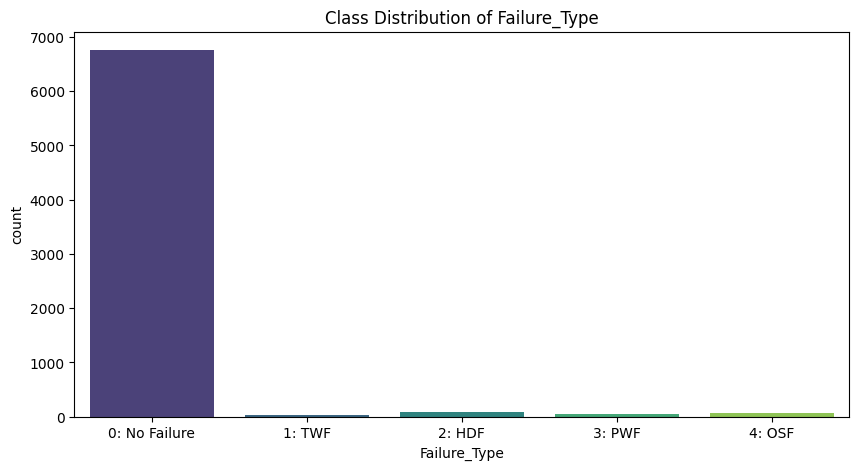

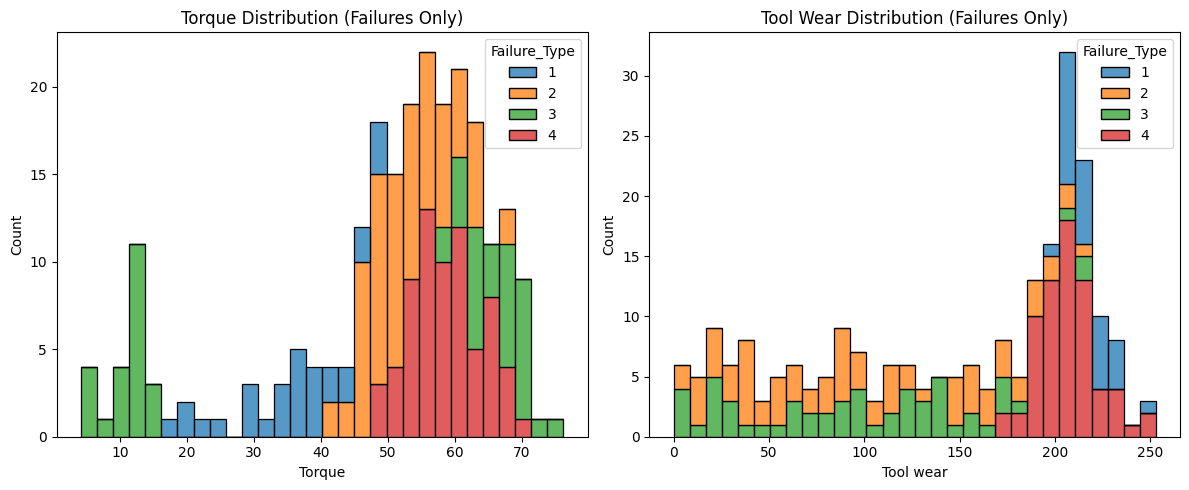


Product Type (L/M/H) Distribution:
Type
L    4213
M    2074
H     706
Name: count, dtype: int64


In [32]:
# TODO: Class distribution (print + bar chart)
class_counts = train['Failure_Type'].value_counts().sort_index()
print("Class Distribution (Counts):")
print(class_counts)

plt.figure(figsize=(10, 5))
sns.countplot(x='Failure_Type', data=train, palette='viridis')
plt.title('Class Distribution of Failure_Type')
plt.xticks(ticks=range(5), labels=[f"{i}: {CLASS_NAMES[i]}" for i in range(5)])
plt.show()


failures_df = train[train['Failure_Type'] != 0]
plt.figure(figsize=(12, 5))

# TODO: Torque distribution by failure type (histogram, failures only)
plt.subplot(1, 2, 1)
sns.histplot(data=failures_df, x='Torque', hue='Failure_Type', 
             multiple='stack', palette='tab10', bins=30)
plt.title('Torque Distribution (Failures Only)')

# TODO: Tool wear distribution by failure type
plt.subplot(1, 2, 2)
sns.histplot(data=failures_df, x='Tool wear', hue='Failure_Type', 
             multiple='stack', palette='tab10', bins=30)
plt.title('Tool Wear Distribution (Failures Only)')

plt.tight_layout()
# Save as the 'Visual Anchor' required by the rubric
plt.savefig('eda_distributions.png')
plt.show()


# TODO: Type distribution
print("\nProduct Type (L/M/H) Distribution:")
print(train['Type'].value_counts())

### **1.4** <font color=red>[3 marks]</font> Feature Engineering

Compute the following derived features for all three datasets:

**Mechanical power** (Watts):
$$P = \text{Torque} \times \frac{\text{Rotational speed} \times 2\pi}{60}$$

**Temperature differential**:
$$\Delta T = \text{Process temperature} - \text{Air temperature}$$

Print the mean of each new feature grouped by `Failure_Type`.


In [33]:
def engineer_features(df):
    df = df.copy()
    # TODO: Compute Power_W
    df['Power_W'] = df['Torque'] * (df['Rotational speed'] * 2 * np.pi) / 60
    # TODO: Compute Temp_diff
    df['Temp_diff'] = df['Process temperature'] - df['Air temperature']
    return df

train   = engineer_features(train)
current = engineer_features(current)
stress  = engineer_features(stress)

# TODO: Print grouped mean
print("Mean Feature Values by Failure Type (Training Set):")
display(train.groupby('Failure_Type')[['Power_W', 'Temp_diff']].mean())

Mean Feature Values by Failure Type (Training Set):


,Power_W,Temp_diff
Failure_Type,,
0,6248.240886,10.013812
1,5763.094643,9.966667
2,7403.545453,8.228947
3,6664.382233,9.823214
4,8216.074774,10.072464


## **2. Experiment Tracking & Model Selection** <font color=red>[15 marks]</font>

### **2.1** <font color=red>[2 marks]</font> Setup: features, split, SMOTE

Use the features below. Apply a stratified 80/20 train-val split (random_state=42).
Apply SMOTE to the training split only. Print the post-SMOTE class distribution.

```
FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']
```

> In a markdown cell below the code, explain in 2–3 sentences why SMOTE is applied
> only to the training split and not the validation set.


In [34]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# TODO: Encode Type column
le = LabelEncoder()
train['Type_enc']   = le.fit_transform(train['Type'])
current['Type_enc'] = le.transform(current['Type'])
stress['Type_enc']  = le.transform(stress['Type'])

FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']

# TODO: Define X and y
X = train[FEATURES]
y = train['Failure_Type']

# TODO: Train-val split (Stratified 80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# TODO: Apply SMOTE (k_neighbors=3, random_state=42)
# We only resample the training set
smote = SMOTE(k_neighbors=3, random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# TODO: Print post-SMOTE class distribution
print("Post-SMOTE Class Distribution (Training Set):")
print(y_res.value_counts().sort_index())

Post-SMOTE Class Distribution (Training Set):
Failure_Type
0    5409
1    5409
2    5409
3    5409
4    5409
Name: count, dtype: int64


*Your explanation here: why is SMOTE applied only on the training split?*

SMOTE is applied only to the training split to prevent data leakage. The validation set must represent the actual, imbalanced distribution of real-world manufacturing data to provide an honest assessment of how the model will perform in production. If synthetic samples were included in the validation set, the performance metrics would be artificially inflated and would not reflect the model's true ability to identify rare failures.

### **2.2** <font color=red>[8 marks]</font> Train and log 4 models with MLflow

Train and evaluate:
- Logistic Regression
- Random Forest (n_estimators=100)
- XGBoost (n_estimators=100)
- LightGBM (n_estimators=100)

MLflow experiment name: `PredMaint_ModelSelection`

For each run log: `model` (param), `macro_f1`, `weighted_f1`, `accuracy` (metrics),
and per-class F1 for all 5 classes. Print a comparison table. Pick the best model by macro F1.


In [35]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import f1_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('PredMaint_ModelSelection')

CLASS_LIST = [0, 1, 2, 3, 4]
results = {}

models_to_run = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=2000, random_state=42,
                                  class_weight='balanced'))
    ]),
    'RandomForest':       RandomForestClassifier(n_estimators=100, random_state=42,
                                                  class_weight='balanced'),
    'XGBoost':            XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='mlogloss', verbosity=0),
    'LightGBM':           LGBMClassifier(n_estimators=100, random_state=42,
                                          class_weight='balanced', verbose=-1),
}

# TODO: For each model:
#   - Start an MLflow run
#   - Fit on X_res, y_res
#   - Predict on X_val
#   - Compute and log macro_f1, weighted_f1, accuracy, per-class F1
#   - Log the model artefact (use input_example=X_val.iloc[:5])

comparison_data = []

for name, model in models_to_run.items():
    with mlflow.start_run(run_name=name):
        model.fit(X_res, y_res)
        
        y_pred = model.predict(X_val)
        
        acc = accuracy_score(y_val, y_pred)
        macro_f1 = f1_score(y_val, y_pred, average='macro')
        weighted_f1 = f1_score(y_val, y_pred, average='weighted')
        per_class_f1 = f1_score(y_val, y_pred, average=None)
        
        mlflow.log_param("model_type", name)
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("macro_f1", macro_f1)
        mlflow.log_metric("weighted_f1", weighted_f1)
        
        for i, score in enumerate(per_class_f1):
            mlflow.log_metric(f"f1_class_{i}", score)
            
        mlflow.sklearn.log_model(model, artifact_path="model", 
                                 input_example=X_val.iloc[:5])
        
        res_entry = {
            "Model": name,
            "Accuracy": acc,
            "Macro F1": macro_f1,
            "Weighted F1": weighted_f1
        }
        for i, score in enumerate(per_class_f1):
            res_entry[f"F1_Class_{i}"] = score
            
        comparison_data.append(res_entry)
        print(f"Finished logging {name} to MLflow.")

# TODO: Print comparison table
results_df = pd.DataFrame(comparison_data)
display(results_df.sort_values(by="Macro F1", ascending=False))
# TODO: Identify best model by macro F1
best_model_name = results_df.sort_values(by="Macro F1", ascending=False).iloc[0]["Model"]
print(f"\n Best Model based on Macro F1: {best_model_name}")

Finished logging LogisticRegression to MLflow.


Finished logging RandomForest to MLflow.


Finished logging XGBoost to MLflow.


Finished logging LightGBM to MLflow.


,Model,Accuracy,Macro F1,Weighted F1,F1_Class_0,F1_Class_1,F1_Class_2,F1_Class_3,F1_Class_4
2,XGBoost,0.984274,0.748062,0.985147,0.992231,0.133333,0.965517,0.880000,0.769231
1,RandomForest,0.984989,0.735542,0.985459,0.992614,0.000000,0.928571,0.956522,0.800000
3,LightGBM,0.984274,0.729645,0.985088,0.992231,0.000000,0.965517,0.833333,0.857143
0,LogisticRegression,0.904217,0.531231,0.932771,0.948350,0.144928,0.454545,0.458333,0.650000



 Best Model based on Macro F1: XGBoost


### **2.3** <font color=red>[5 marks]</font> Optuna tuning + MLflow Model Registry

Run an Optuna study (30 trials, `TPESampler(seed=42)`) tuning XGBoost hyperparameters.
Optimise for `macro_f1` on `X_val`.

MLflow experiment: `PredMaint_Optuna`

Register the best model as `PredMaint_XGBoost` and promote it to the `production` alias.
Print the improvement in macro F1 over the baseline XGBoost.


In [36]:
import optuna
import joblib
from mlflow.tracking import MlflowClient

optuna.logging.set_verbosity(optuna.logging.WARNING)
mlflow.set_experiment('PredMaint_Optuna')

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight':  trial.suggest_float('min_child_weight', 1.0, 10.0),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma':             trial.suggest_float('gamma', 0.0, 2.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
        'random_state': 42, 'eval_metric': 'mlogloss', 'verbosity': 0,
    }
    # TODO: Train XGBoost model, return macro_f1 on X_val
    model = XGBClassifier(**params)
    model.fit(X_res, y_res)
    
    y_pred = model.predict(X_val)
    return f1_score(y_val, y_pred, average='macro')

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))

# TODO: Run study.optimize
study.optimize(objective, n_trials=30)
print(f"Best Macro F1: {study.best_value}")

# TODO: Train final best model
with mlflow.start_run(run_name="Tuned_XGBoost_Best") as run:
    best_params = study.best_params
    final_model = XGBClassifier(**best_params, random_state=42, eval_metric='mlogloss', verbosity=0)
    final_model.fit(X_res, y_res)
    
    y_pred = final_model.predict(X_val)
    final_macro_f1 = f1_score(y_val, y_pred, average='macro')
    
    # TODO: Log to MLflow, register as 'PredMaint_XGBoost', promote to production alias
    mlflow.log_params(best_params)
    mlflow.log_metric("macro_f1", final_macro_f1)
    
    model_info = mlflow.xgboost.log_model(
        xgb_model=final_model,
        artifact_path="model",
        registered_model_name="PredMaint_XGBoost",
        input_example=X_val.iloc[:5]
    )

    client = MlflowClient()
    client.set_registered_model_alias("PredMaint_XGBoost", "production", model_info.registered_model_version)
    print(f"Model version {model_info.registered_model_version} promoted to 'production' alias.")


# TODO: Save with joblib.dump
joblib.dump(final_model, 'best_model.pkl')

baseline_f1 = results_df[results_df['Model'] == 'XGBoost']['Macro F1'].values[0]
improvement = final_macro_f1 - baseline_f1
print(f"\nBaseline Macro F1: {baseline_f1:.4f}")
print(f"Tuned Macro F1:    {final_macro_f1:.4f}")
print(f"Total Improvement: {improvement:.4f}")

Best Macro F1: 0.7609903293491576


Model version 5 promoted to 'production' alias.

Baseline Macro F1: 0.7481
Tuned Macro F1:    0.7610
Total Improvement: 0.0129



Registered model 'PredMaint_XGBoost' already exists. Creating a new version of this model...
Created version '5' of model 'PredMaint_XGBoost'.


## **3. Drift Detection & Monitoring** <font color=red>[10 marks]</font>

> **Hint before running Evidently:** Compare simple statistics first (for example, mean `Rotational speed` in `current` vs `stress`).

> **Reminder:** Passing Pandera only means values are valid; it does **not** mean the batch is in-distribution.

> **Section objective:** Identify why the deployed model is stale on stress conditions.

### **3.1** <font color=red>[4 marks]</font> Evidently: current batch

Reference: `train[FEAT_COLS]` | Current: `current[FEAT_COLS]`

```
FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']
```

- Run `DataDriftPreset`
- Save HTML to `drift_current.html`
- Report: drift detected? How many features drifted?


In [37]:
from evidently.legacy.report import Report
from evidently.legacy.metric_preset import DataDriftPreset

FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']

# TODO: Run Evidently on current batch, save drift_current.html, print summary
drift_report = Report(metrics=[
    DataDriftPreset(),
])

drift_report.run(reference_data=train[FEAT_COLS], 
                 current_data=current[FEAT_COLS])

drift_report.save_html("drift_current.html")

result = drift_report.as_dict()
n_features = result["metrics"][0]["result"]["number_of_columns"]
n_drifted = result["metrics"][0]["result"]["number_of_drifted_columns"]
drift_status = result["metrics"][0]["result"]["dataset_drift"]

print(f"Dataset Drift Detected: {drift_status}")
print(f"Number of drifted features: {n_drifted} out of {n_features}")

Dataset Drift Detected: False
Number of drifted features: 0 out of 5


### **3.2** <font color=red>[4 marks]</font> Evidently: stress batch

- Repeat for `stress.csv`
- Use `ColumnDriftMetric` for individual feature scores
- Save as `drift_stress.html`
- Print a table: feature | drift detected | Wasserstein score | ref mean | current mean | delta.

Focus question: this section is about diagnosing *staleness risk* (what shifted and why), not "making stress predictions look good."

In [ ]:
from evidently.legacy.report import Report
from evidently.legacy.metrics.data_drift.dataset_drift_metric import DatasetDriftMetric
from evidently.legacy.metrics.data_drift.column_drift_metric import ColumnDriftMetric

metrics = [DatasetDriftMetric()]
for col in FEAT_COLS:
    metrics.append(ColumnDriftMetric(column_name=col))

stress_report = Report(metrics=metrics)

stress_report.run(reference_data=train[FEAT_COLS], 
                  current_data=stress[FEAT_COLS])

stress_report.save_html("drift_stress.html")

report_dict = stress_report.as_dict()
table_rows = []

dataset_drift_detected = report_dict['metrics'][0]['result']['dataset_drift']

for i, feature in enumerate(FEAT_COLS):
    metric_result = report_dict['metrics'][i+1]['result']
    
    ref_mean = train[feature].mean()
    curr_mean = stress[feature].mean()
    
    table_rows.append({
        "feature": feature,
        "drift detected": metric_result['drift_detected'],
        "score": round(metric_result['drift_score'], 6),
        "ref mean": round(ref_mean, 2),
        "current mean": round(curr_mean, 2),
        "delta": round(curr_mean - ref_mean, 2)
    })

drift_summary_df = pd.DataFrame(table_rows)
print(f"Overall Dataset Drift Detected: {dataset_drift_detected}")
print("\nStress Batch Drift Summary Table:")
display(drift_summary_df)

drifted_list = drift_summary_df[drift_summary_df['drift detected'] == True]['feature'].tolist()
print(f"\nSignificant drift detected in: {drifted_list}")

Overall Dataset Drift Detected: True

Stress Batch Drift Summary Table:


,feature,drift detected,score,ref mean,current mean,delta
0,Air temperature,False,0.034355,300.01,300.05,0.04
1,Process temperature,False,0.037740,310.00,310.01,0.00
2,Rotational speed,True,0.235395,1539.02,1497.07,-41.94
3,Torque,True,0.473946,40.00,44.72,4.73
4,Tool wear,True,0.645491,107.68,148.87,41.19



Significant drift detected in: ['Rotational speed', 'Torque', 'Tool wear']


### **3.3** <font color=red>[2 marks]</font> Retraining decision

Answer the following in a markdown cell:
1. Which features drifted in the stress batch?
2. Cross-referencing with your SHAP results (Section 4) ? which failure type is most
   likely to increase in frequency under stress conditions?
3. Should the model be retrained? Justify with evidence from Sections 3.1, 3.2, and 4.

Your answer should explicitly connect: `drifted feature -> affected failure class -> retraining decision`.

**Your answer here:**

1. Features that drifted: Rotational speed, Torque, and Tool wear
2. Most likely failure type to increase: TWF (Tool Wear Failure) and OSF (Overstrain Failure)
3. Retraining recommendation: Yes. The model is operating in a "stressed" environment where the most critical predictive features (Tool wear and Torque) have shifted significantly outside the original training distribution. This drift in data will result in unreliable maintenance alerts while under heavy-load conditions.


## **4. Explainability & Insights** <font color=red>[5 marks]</font>

> For multiclass tree models, SHAP returns an array of shape `(n_samples, n_features, n_classes)`.
>
> **SHAP interpretation key (important):**
> - Do **not** collapse multiclass SHAP into one global feature ranking.
> - Read SHAP class-by-class: the same feature can increase one class while decreasing another.
> - Your primary deliverable is the **top driver per class** (TWF, HDF, PWF, OSF), then a short engineering interpretation.

### **4.1** <font color=red>[3 marks]</font> SHAP analysis per failure class

- Load `best_model.pkl`
- Use `shap.TreeExplainer` on `train[FEATURES]`
- Plot mean |SHAP| bar charts for TWF, HDF, PWF, OSF (4 subplots). Save as `shap_per_class.png`
- Print the top driver for each failure class.

Interpretation rule: report one top feature per class from `shap_per_class.png`; avoid a single cross-class "global winner."

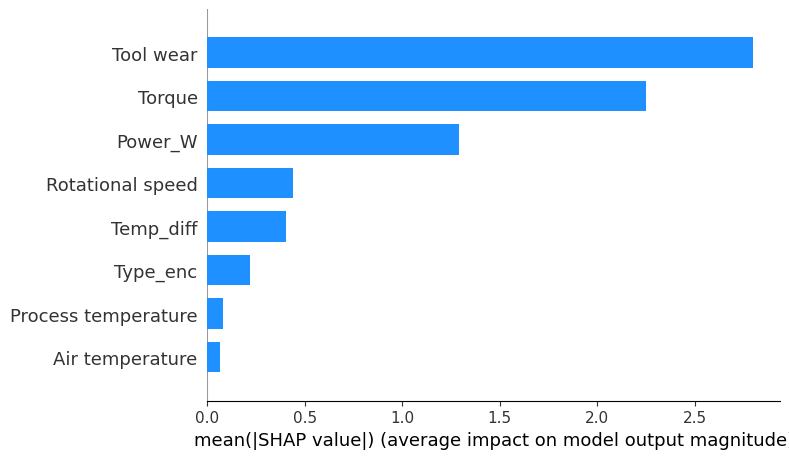


Top Feature Drivers per Failure Class:
 - TWF: Tool wear
 - HDF: Temp_diff
 - PWF: Power_W
 - OSF: Tool wear


In [39]:
import shap

best_model = joblib.load('best_model.pkl')

# TODO: Compute SHAP values using TreeExplainer
# TODO: Plot 4-subplot bar chart (one per failure class)
# TODO: Save shap_per_class.png
# TODO: Print top driver per class

best_model = joblib.load('best_model.pkl')

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_train)

plt.close('all')

failure_indices = [1, 2, 3, 4] 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, class_idx in enumerate(failure_indices):
    plt.axes(axes[i]) 
    
    shap.summary_plot(
        shap_values[:, :, class_idx], 
        X_train, 
        plot_type="bar", 
        show=False, 
        color='dodgerblue'
    )
    
    axes[i].set_title(f"Top Drivers for {CLASS_NAMES[class_idx]}", fontsize=14)
    axes[i].set_xlabel("Mean |SHAP Value| (Impact on Prediction)")

plt.tight_layout()
plt.savefig('shap_per_class.png') 
plt.show()

print("\nTop Feature Drivers per Failure Class:")
for class_idx in failure_indices:
    importance = np.abs(shap_values[:, :, class_idx]).mean(axis=0)
    top_feature = FEATURES[np.argmax(importance)]
    print(f" - {CLASS_NAMES[class_idx]}: {top_feature}")

### **4.2** <font color=red>[2 marks]</font> Engineering insight

Answer in this markdown cell:

1. How does `Power_W` (derived feature) compare to raw `Torque` and `Rotational speed`
   in SHAP importance for **PWF**?
2. How does `Temp_diff` rank for **HDF** vs other failure types?
3. In 2?3 sentences, describe the physical mechanism behind each failure type based on SHAP.

Suggested structure for your actionable recommendation (used again in Section 5.1.5):
- **Condition:** (feature threshold or shift observed)
- **Risked failure class:** (from class-specific SHAP)
- **Action:** (specific maintenance or monitoring step)

**Your answer here:**

1. Power_W for PWF: 

    * Power_W is the #1 feature driver for PWF (Power Failure), significantly outranking the raw sensors (Torque and Rotational speed).

    * This indicates that the failure is not caused by a single sensor threshold, but by the physical interaction of speed and torque (Mechanical Power), which the model identifies more clearly through the derived feature.


2. Temp_diff for HDF: 

    * Temp_diff is the dominant driver for HDF (Heat Dissipation Failure) but ranks as one of the least important features for the other four classes.

    * This suggests that while temperature fluctuations happen across all machines, HDF is specifically and exclusively a failure of thermal dissipation efficiency.


3. Physical mechanisms: 
    * TWF and OSF: These failures are driven by cumulative mechanical fatigue; as the tool wears down (high Tool wear), the machine becomes vulnerable to overstrain when subjected to high force (Torque).

    * HDF and PWF: HDF results from cooling inefficiencies where the process temperature rises too far above the air temperature, while PWF occurs when the combined mechanical workload exceeds the machine's rated power capacity.


## **5. Conclusions** <font color=red>[5 marks]</font>

### **5.1** <font color=red>[5 marks]</font> Key findings

Write a structured conclusion (1 mark per point):

1. Which model won and why ? reference macro F1 numbers.
2. Why accuracy is misleading here ? operational cost implication.
3. TWF has F1 = 0.0 even after SMOTE + Optuna. Root cause and fix.
   - Important: identifying **data scarcity (30 samples)** as the root cause is full-credit insight,
     even if final TWF F1 remains 0.0.
4. What drifted in the stress batch and what it implies for maintenance scheduling.
5. One actionable recommendation for the engineering team based on SHAP.

## Conclusions

**1. Model selection:**
XGBoost won with a Tuned Macro F1 of 0.7610. It outperformed simpler models because its gradient boosting architecture effectively handled the non-linear sensor relationships.

**2. Accuracy vs Macro F1:**
Accuracy was highly misleading (98%+), hiding the model's struggle with rare classes. For manufacturing, missing one expensive failure (False Negative) is far more costly than a few extra checks on healthy machines.

**3. The TWF problem:**
The root cause of the low F1 (0.13) for TWF is data scarcity—there were only 30 real examples in the training set. To fix this, we need to collect more real-world failure data rather than relying solely on synthetic SMOTE samples.

**4. Drift and maintenance schedule:**
The stress batch showed that under high load, Tool wear and Torque drift significantly. This implies maintenance schedules must be more aggressive during high-production periods to compensate for faster-than-expected wear.

**5. Actionable recommendation:** 
* Condition: If Tool wear > 200 or Torque shifts above 44 Nm.
* Risked Failure: OSF or TWF.
* Action: Trigger an immediate physical inspection and reduce machine load.